<a href="https://colab.research.google.com/github/SinhaPushkar047/ML_Learning_Projects/blob/main/07-Bank-Deposit-Prediction/Bank_Deposit_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [179]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score

In [63]:
depo=pd.read_csv('https://raw.githubusercontent.com/SinhaPushkar047/ML_Learning_Projects/refs/heads/main/07-Bank-Deposit-Prediction/bank.csv')

In [64]:
depo

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


# **EDA**

In [65]:
cat_col=[col for col in depo.columns if depo[col].dtype=='object' and col not in 'deposit']

In [66]:
num_col=[col for col in depo.columns if depo[col].dtype=='int64']

In [67]:
depo[num_col].skew().sort_values()

,0
day,0.111330
age,0.862780
duration,2.143695
pdays,2.449986
campaign,5.545578
previous,7.335298
balance,8.224619


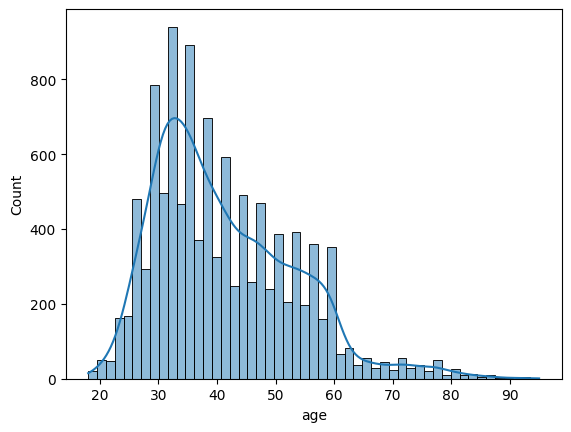

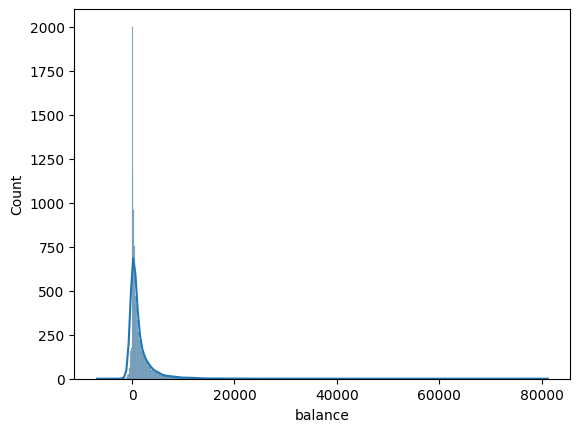

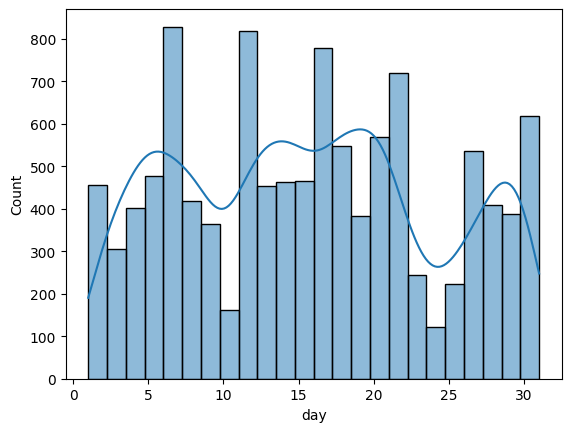

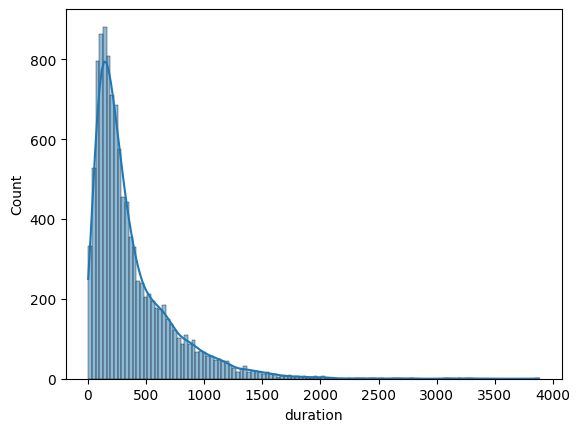

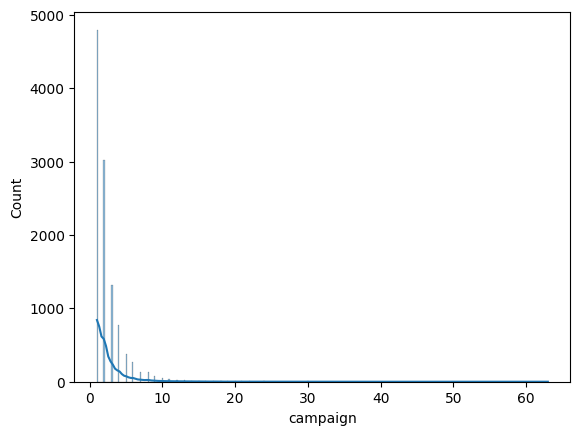

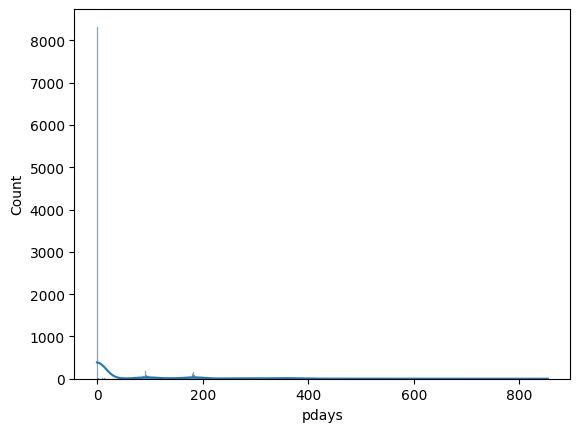

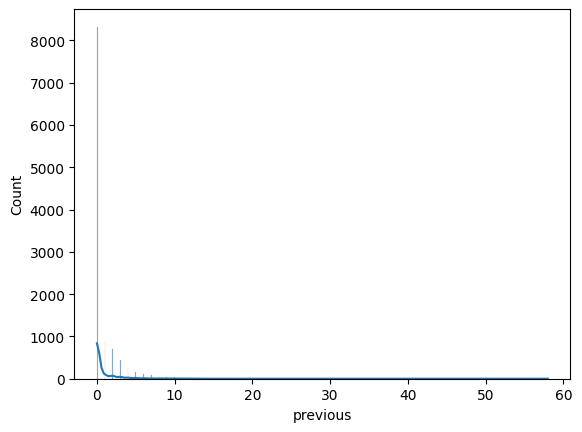

In [68]:
for i in num_col:
  sns.histplot(depo[i],kde=True)
  plt.show()

# **Encoding & Scaling**

In [69]:
depo['deposit']=LabelEncoder().fit_transform(depo['deposit'])

In [70]:
x_train,x_test,y_train,y_test=train_test_split(depo.drop(columns='deposit'),depo['deposit'],test_size=0.2,random_state=42)

In [71]:
depo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 1.4+ MB


In [72]:
trf=ColumnTransformer([
    ('ohe',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cat_col),
    ('scale',StandardScaler(),num_col),
    ('power',PowerTransformer(),num_col)
],remainder='passthrough')

In [73]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)

# **PCA**

In [111]:
pca_full=PCA()

In [112]:
pca_full.fit(x_train_trf)

PCA()

In [114]:
cum_var=np.cumsum(pca_full.explained_variance_ratio_)

Text(0, 0.5, 'PCA Variance Explained')

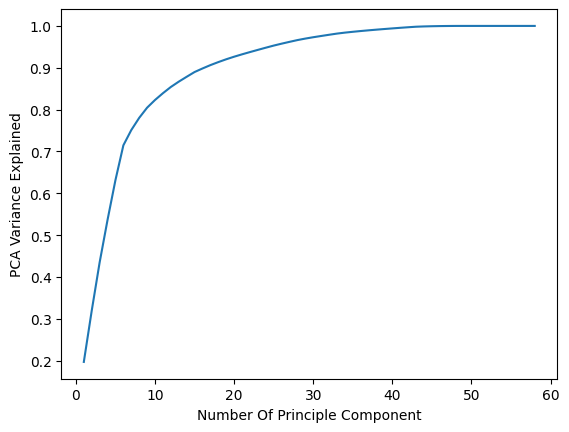

In [117]:
plt.plot(range(1,len(cum_var)+1),cum_var)
plt.xlabel("Number Of Principle Component")
plt.ylabel("PCA Variance Explained")

In [123]:
threshold=0.99
n_component=np.argmax(cum_var>=threshold)+1
print(n_component)

38


# **Naive Bayes**

**Gaussian NB**

In [139]:
pipe_nb=Pipeline([
    ('PCA',PCA(n_components=38)),
    ('model',GaussianNB())
])

In [140]:
param_grid = {'model__var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9,1e-8, 1e-7, 1e-6, 1e-5]
}

In [141]:
grid_nb=GridSearchCV(pipe,param_grid=param_grid,cv=5,verbose=2,scoring='f1',n_jobs=-1)

In [142]:
grid_nb.fit(x_train_trf,y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('PCA', PCA(n_components=38)),
                                       ('model', GaussianNB())]),
             n_jobs=-1,
             param_grid={'model__var_smoothing': [1e-12, 1e-11, 1e-10, 1e-09,
                                                  1e-08, 1e-07, 1e-06, 1e-05]},
             scoring='f1', verbose=2)

In [143]:
y_gnb_pred=grid_nb.predict(x_test_trf)

In [144]:
grid_nb.best_params_

{'model__var_smoothing': 1e-05}

In [145]:
grid_nb.best_score_*100

np.float64(67.80143881200263)

In [146]:
print(classification_report(y_test,y_gnb_pred))

              precision    recall  f1-score   support

           0       0.71      0.79      0.75      1166
           1       0.74      0.66      0.69      1067

    accuracy                           0.72      2233
   macro avg       0.73      0.72      0.72      2233
weighted avg       0.73      0.72      0.72      2233



# **KNN**

In [147]:
pipe_knn=Pipeline([
    ('PCA',PCA(n_components=38)),
    ('model',KNeighborsClassifier())
])

In [148]:
param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan', 'minkowski'],
    'model__p': [1, 2]
}

In [149]:
grid_knn=GridSearchCV(pipe_knn,param_grid,cv=5,verbose=3,scoring='f1',n_jobs=-1)

In [150]:
grid_knn.fit(x_train_trf,y_train)

Fitting 5 folds for each of 84 candidates, totalling 420 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('PCA', PCA(n_components=38)),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'model__metric': ['euclidean', 'manhattan',
                                           'minkowski'],
                         'model__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
                         'model__p': [1, 2],
                         'model__weights': ['uniform', 'distance']},
             scoring='f1', verbose=3)

In [151]:
grid_knn.best_params_

{'model__metric': 'euclidean',
 'model__n_neighbors': 21,
 'model__p': 1,
 'model__weights': 'distance'}

In [152]:
grid_knn.best_score_*100

np.float64(81.24000176327992)

In [153]:
y_knn=grid_knn.predict(x_test_trf)

In [154]:
print(classification_report(y_knn,y_test))

              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1146
           1       0.82      0.80      0.81      1087

    accuracy                           0.82      2233
   macro avg       0.82      0.82      0.82      2233
weighted avg       0.82      0.82      0.82      2233



## **Changing Threshold by ROC**

In [184]:
y_prob_knn = grid_knn.predict_proba(x_test_trf)[:, 1]

In [185]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)

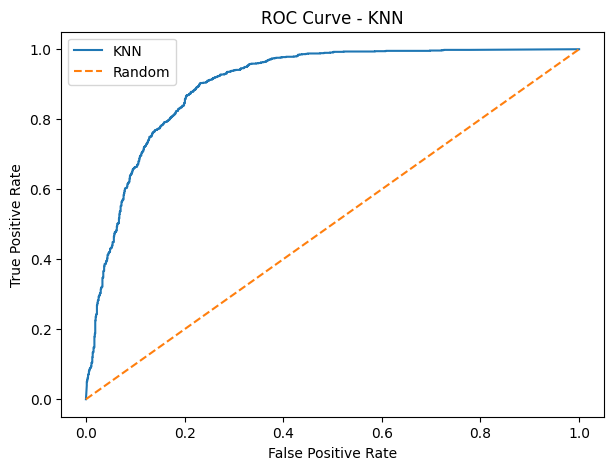

In [186]:
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label='KNN')

plt.plot([0, 1], [0, 1], '--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend()
plt.show()

In [187]:
auc_knn = roc_auc_score(y_test, y_prob_knn)

print("KNN ROC-AUC:", auc_knn)

KNN ROC-AUC: 0.901146350599057


In [188]:
distance = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)

best_idx = np.argmin(distance)

best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("TPR:", tpr[best_idx])
print("FPR:", fpr[best_idx])

Best threshold: 0.4461706359835236
TPR: 0.8669165885660731
FPR: 0.2032590051457976


In [189]:
y_knn_threshold = (y_prob_knn >= best_threshold).astype(int)

In [190]:
print(classification_report(y_test, y_knn_threshold))

              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1166
           1       0.80      0.87      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



# **Decision Tree**

In [167]:
pipe_dtc=Pipeline([
    ('dtc',DecisionTreeClassifier())
])

In [168]:
param_grid = {
    'dtc__criterion': ['gini', 'entropy', 'log_loss'],
    'dtc__max_depth': [3, 5, 7, 10, None],
    'dtc__min_samples_split': [2, 5, 10],
    'dtc__min_samples_leaf': [1, 2, 5, 10]
}

In [169]:
grid_dt=GridSearchCV(pipe_dtc,param_grid,cv=5,verbose=3,scoring='f1',n_jobs=-1)

In [170]:
grid_dt.fit(x_train_trf,y_train)

Fitting 5 folds for each of 180 candidates, totalling 900 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('dtc', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'dtc__criterion': ['gini', 'entropy', 'log_loss'],
                         'dtc__max_depth': [3, 5, 7, 10, None],
                         'dtc__min_samples_leaf': [1, 2, 5, 10],
                         'dtc__min_samples_split': [2, 5, 10]},
             scoring='f1', verbose=3)

In [171]:
grid_dt.best_score_*100

np.float64(82.3244872232635)

In [172]:
grid_dt.best_params_

{'dtc__criterion': 'gini',
 'dtc__max_depth': 10,
 'dtc__min_samples_leaf': 10,
 'dtc__min_samples_split': 2}

In [173]:
y_dtc_pred=grid_dt.predict(x_test_trf)

In [202]:
print(classification_report(y_dtc_pred,y_test))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82      1103
           1       0.84      0.79      0.82      1130

    accuracy                           0.82      2233
   macro avg       0.82      0.82      0.82      2233
weighted avg       0.82      0.82      0.82      2233



## **Changing Threshold**

In [196]:
y_dtc_prob=grid_dt.predict_proba(x_test_trf)[:,1]

In [197]:
fpr, tpr, thresholds = roc_curve(y_test, y_dtc_prob)

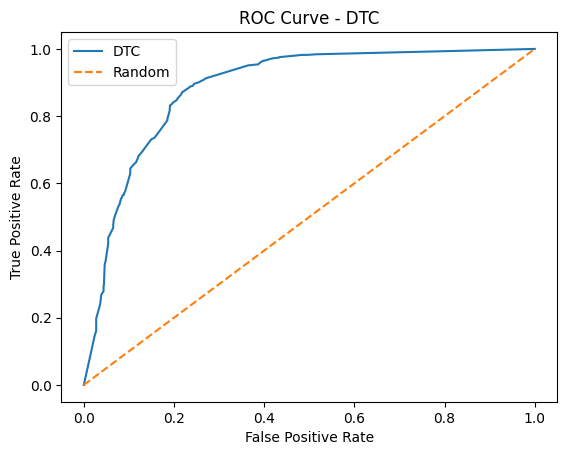

In [200]:
plt.plot(fpr, tpr, label='DTC')

plt.plot([0, 1], [0, 1], '--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DTC')
plt.legend()
plt.show()

In [203]:
auc_dtc = roc_auc_score(y_test, y_dtc_prob)

print("DTC ROC-AUC:", auc_dtc)

DTC ROC-AUC: 0.8844751559734495


In [204]:
distance = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)

best_idx = np.argmin(distance)

best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("TPR:", tpr[best_idx])
print("FPR:", fpr[best_idx])

Best threshold: 0.4166666666666667
TPR: 0.8706654170571696
FPR: 0.21783876500857632


In [206]:
y_dtc_threshold = (y_dtc_prob >= best_threshold).astype(int)

In [208]:
print(classification_report(y_dtc_threshold,y_test))

              precision    recall  f1-score   support

           0       0.78      0.87      0.82      1050
           1       0.87      0.79      0.83      1183

    accuracy                           0.82      2233
   macro avg       0.83      0.83      0.82      2233
weighted avg       0.83      0.82      0.82      2233

